<a href="https://colab.research.google.com/github/Heng1222/Ohsumed_classification/blob/feat-token-size/Model/Token_size_distribution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
# 1. 測試資料集 (Python List of Strings)
# 請將 MeSH descriptor names 讀取為一個純文字列表
# 範例： ["Myocardial Infarction", "Diabetes Mellitus", "Acetylcholinesterase", ...]
import pandas as pd
url = 'https://github.com/Heng1222/Ohsumed_classification/blob/main/MeSH_data/mesh_dataset.csv?raw=true'
full_df = pd.read_csv(url)
mesh_terms_set = set(pd.concat([full_df["word_i"], full_df["word_j"]]))

# 2. 模型字典 (Dictionary of Tokenizers)
# Key 為模型名稱 (自訂)，Value 為已經 load 好的 Hugging Face Tokenizer 物件
# 範例：
# tokenizers_dict = {
#     "Llama-3": AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3-8B"),
#     "BioMistral": AutoTokenizer.from_pretrained("BioMistral/BioMistral-7B"),
#     "Gemma-2": AutoTokenizer.from_pretrained("google/gemma-2-9b")
# }
from transformers import RobertaTokenizer
tokenizers_dict = {
  "RoBERTa": RobertaTokenizer.from_pretrained('roberta-base')
}

正在分析 5080 個 MeSH 詞彙...
Processing RoBERTa...


100%|██████████| 5080/5080 [00:00<00:00, 9858.38it/s]


=== RoBERTa Tokenizer 詳細統計數據 ===


,Token_Count,Chars_per_Token,Fragmentation_Rate
count,5080.000000,5080.000000,5080.000000
mean,5.206693,4.017464,0.087853
std,2.211809,1.360432,0.122236
min,1.000000,0.945946,0.000000
25%,4.000000,3.000000,0.000000
50%,5.000000,3.714286,0.000000
75%,6.000000,4.714286,0.166667
max,37.000000,11.500000,0.666667


/tmp/ipython-input-523318071.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_results, x="Model", y="Token_Count", palette="Set2")


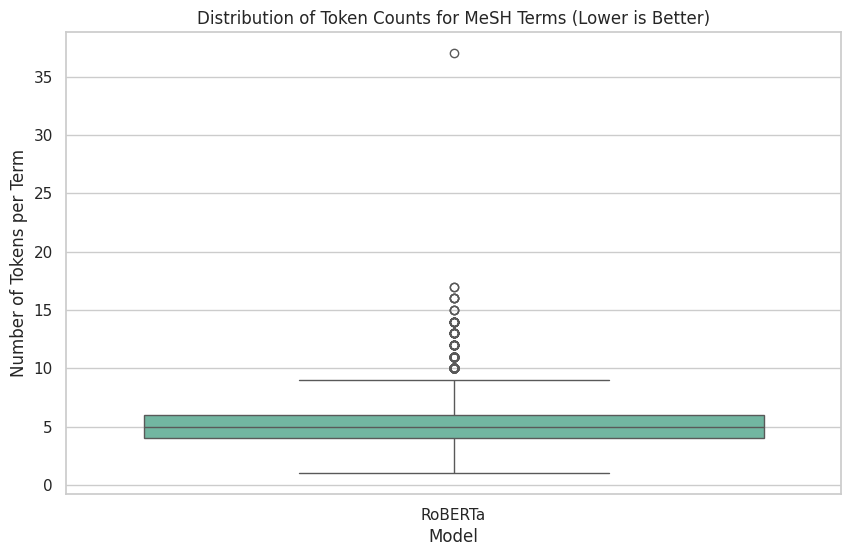

/tmp/ipython-input-523318071.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_results, x="Model", y="Fragmentation_Rate", palette="Set2", inner="quartile")


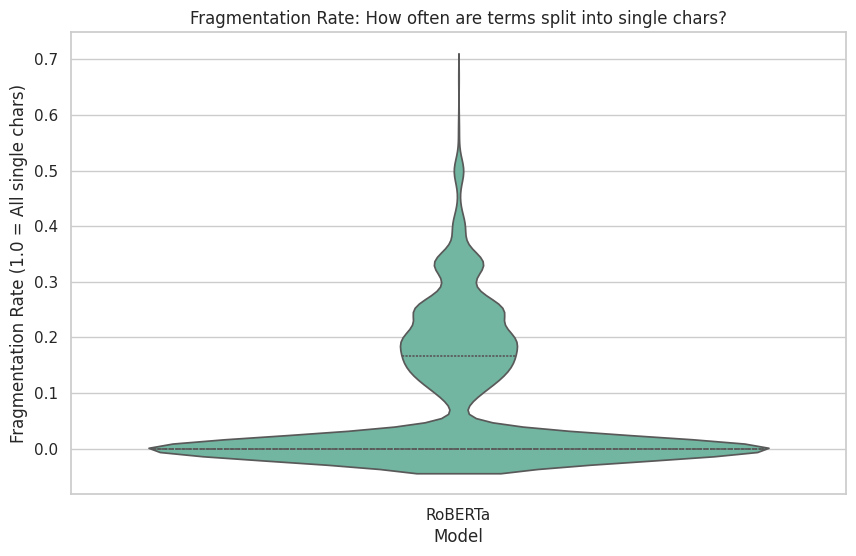

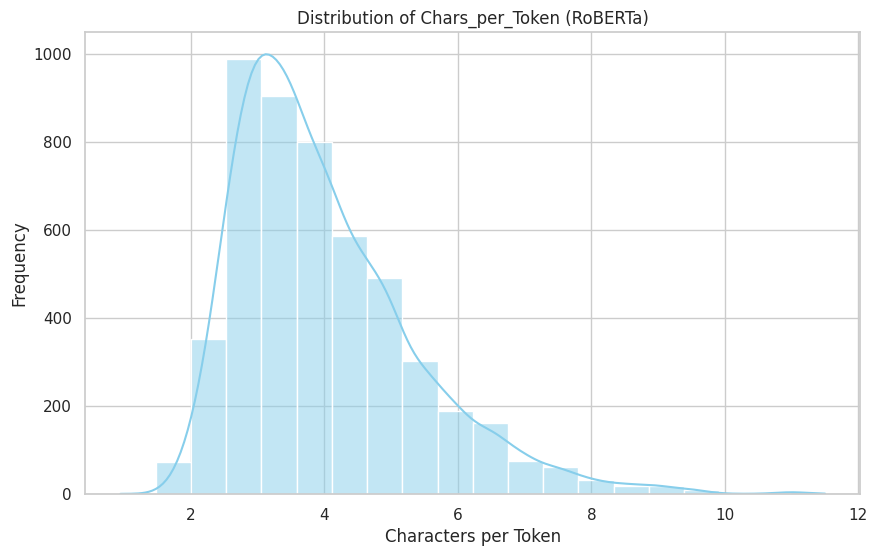

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# --- 設定繪圖風格 ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

def calculate_token_metrics(text, tokenizer, model_name):
    """
    計算單個詞彙在特定 Tokenizer 下的各項指標
    """
    # 重要：add_special_tokens=False 以避免 [BOS]/[CLS] 影響統計
    tokens = tokenizer.tokenize(text, add_special_tokens=False)
    ids = tokenizer.encode(text, add_special_tokens=False)

    token_count = len(tokens)
    char_count = len(text)

    # 避免除以零
    if token_count == 0: return None

    # 1. 字元/Token 比 (Compression Rate): 越高越好，代表一個 Token 能攜帶更多資訊
    chars_per_token = char_count / token_count

    # 2. 碎片化程度 (Fragmentation Score):
    # 計算長度只有 1 的 token (通常是單字母或 byte fallback) 佔總 token 的比例
    # 比例越高代表模型對此詞彙越陌生，被迫拆成字母
    single_char_tokens = sum(1 for t in tokens if len(t.replace('Ġ', '').replace(' ', '')) == 1)
    fragmentation_rate = single_char_tokens / token_count

    return {
        "Model": model_name,
        "Term": text,
        "Char_Length": char_count,
        "Token_Count": token_count,
        "Chars_per_Token": chars_per_token,      # 越高越好 (編碼效率高)
        "Fragmentation_Rate": fragmentation_rate # 越低越好 (0 代表沒有單字母拆解)
    }

def run_mesh_analysis(terms_list, tokenizers_map):
    results = []

    print(f"正在分析 {len(terms_list)} 個 MeSH 詞彙...")

    for model_name, tokenizer in tokenizers_map.items():
        print(f"Processing {model_name}...")
        for term in tqdm(terms_list):
            metrics = calculate_token_metrics(term, tokenizer, model_name)
            if metrics:
                results.append(metrics)

    return pd.DataFrame(results)

# --- 執行分析 ---
# df_results 是你主要的分析表格
df_results = run_mesh_analysis(mesh_terms_set, tokenizers_dict)

# --- 查看數據摘要 ---
# 顯示 RoBERTa 模型的詳細描述性統計
roberta_df = df_results[df_results['Model'] == 'RoBERTa']
print("\n=== RoBERTa Tokenizer 詳細統計數據 ===")
display(roberta_df[["Token_Count", "Chars_per_Token", "Fragmentation_Rate"]].describe())

# 圖表 1: Token Count 分布 (Boxplot)
# 觀察：哪個模型需要的 Token 數最少 (中位數越低越好)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_results, x="Model", y="Token_Count", palette="Set2")
plt.title("Distribution of Token Counts for MeSH Terms (Lower is Better)")
plt.ylabel("Number of Tokens per Term")
plt.show()

# 圖表 2: 碎片化程度 (Violin Plot or Strip Plot)
# 觀察：是否有模型經常出現高碎片化 (Fragmentation > 0.5)
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_results, x="Model", y="Fragmentation_Rate", palette="Set2", inner="quartile")
plt.title("Fragmentation Rate: How often are terms split into single chars?")
plt.ylabel("Fragmentation Rate (1.0 = All single chars)")
plt.show()

# 圖表 3: Chars_per_Token 整體分佈
# 觀察：每個 Token 平均承載的字元數的分佈狀況
plt.figure(figsize=(10, 6))
sns.histplot(data=df_results, x="Chars_per_Token", kde=True, bins=20, color='skyblue')
plt.title("Distribution of Chars_per_Token (RoBERTa)")
plt.xlabel("Characters per Token")
plt.ylabel("Frequency")
plt.show()

### RoBERTa Tokenizer 表現極端範例

In [25]:
# 顯示 Token 數量最多的前 5 個 MeSH 詞彙
print("\n=== Token 數量最多的 MeSH 詞彙 (RoBERTa) ===")
display(roberta_df.sort_values(by='Chars_per_Token', ascending=True).head(30))


=== Token 數量最多的 MeSH 詞彙 (RoBERTa) ===


,Model,Term,Char_Length,Token_Count,Chars_per_Token,Fragmentation_Rate
3091,RoBERTa,нервной системы центральной болезни,35,37,0.945946,0.243243
4112,RoBERTa,covid-19,8,5,1.600000,0.400000
4982,RoBERTa,pinta,5,3,1.666667,0.666667
3443,RoBERTa,nevus,5,3,1.666667,0.333333
857,RoBERTa,dyspnea,7,4,1.750000,0.500000
429,RoBERTa,sarcoma,7,4,1.750000,0.500000
310,RoBERTa,bruxism,7,4,1.750000,0.500000
4798,RoBERTa,dyspepsia,9,5,1.800000,0.200000
2724,RoBERTa,dysgeusia,9,5,1.800000,0.200000
601,RoBERTa,pemphigus,9,5,1.800000,0.200000


In [26]:
# 顯示碎片化率最高的前 5 個 MeSH 詞彙 (表示這些詞彙被拆解成單字元的比例最高)
print("\n=== 碎片化率最高的 MeSH 詞彙 (RoBERTa) ===")
display(roberta_df.sort_values(by='Fragmentation_Rate', ascending=False).head(5))


=== 碎片化率最高的 MeSH 詞彙 (RoBERTa) ===


,Model,Term,Char_Length,Token_Count,Chars_per_Token,Fragmentation_Rate
190,RoBERTa,nausea,6,3,2.000000,0.666667
4982,RoBERTa,pinta,5,3,1.666667,0.666667
2831,RoBERTa,vitamin b 6 deficiency,22,5,4.400000,0.600000
1486,RoBERTa,tay-sachs disease,17,7,2.428571,0.571429
3692,RoBERTa,fetus-in-fetu,13,7,1.857143,0.571429


# Task
Analyze the RoBERTa tokenizer's performance by comparing its tokenization metrics (Token Count, Characters per Token, and Fragmentation Rate) on two datasets: the existing MeSH terms and a new dataset of everyday words. Please provide the everyday words as a Python list of strings. The analysis will involve merging the results, comparing descriptive statistics, and visualizing the distributions of these metrics for both datasets, followed by a summary report of the findings.

## 準備現有 MeSH 結果

### Subtask:
將現有的 `df_results` DataFrame 添加一個名為 `Dataset_Type` 的新欄位，並將其值設定為 'MeSH Terms'，以便後續與新資料集進行區分。


**Reasoning**:
To differentiate the current dataset from future ones, a new column `Dataset_Type` needs to be added to `df_results` DataFrame and populated with 'MeSH Terms'.



In [27]:
df_results['Dataset_Type'] = 'MeSH Terms'
print(df_results.head())

     Model                   Term  Char_Length  Token_Count  Chars_per_Token  \
0  RoBERTa               dystonia            8            3         2.666667   
1  RoBERTa  food hypersensitivity           21            3         7.000000   
2  RoBERTa                 ataxia            6            3         2.000000   
3  RoBERTa                 glioma            6            3         2.000000   
4  RoBERTa            spondylitis           11            4         2.750000   

   Fragmentation_Rate Dataset_Type  
0            0.000000   MeSH Terms  
1            0.000000   MeSH Terms  
2            0.000000   MeSH Terms  
3            0.333333   MeSH Terms  
4            0.000000   MeSH Terms  


**Reasoning**:
The next step is to prepare the new dataset of everyday words, which will be used for comparison with the MeSH terms. This involves creating a Python list of common English words.



In [28]:
everyday_words = [
    "apple", "banana", "car", "house", "computer",
    "dog", "cat", "tree", "flower", "water",
    "sun", "moon", "star", "cloud", "sky",
    "book", "pen", "table", "chair", "door",
    "window", "phone", "shirt", "shoe", "road",
    "city", "river", "mountain", "ocean", "forest",
    "happy", "sad", "big", "small", "good",
    "bad", "fast", "slow", "hot", "cold",
    "eat", "sleep", "walk", "run", "talk",
    "read", "write", "play", "work", "learn"
]

print(f"Created a list of {len(everyday_words)} everyday words.")


Created a list of 50 everyday words.


**Reasoning**:
Now that the `everyday_words` list has been created, it needs to be processed by the tokenizer to obtain its tokenization metrics. The `run_mesh_analysis` function can be reused for this purpose, and the results will be stored in a new DataFrame.



In [29]:
df_everyday_words_results = run_mesh_analysis(everyday_words, tokenizers_dict)
df_everyday_words_results['Dataset_Type'] = 'Everyday Words'
print(df_everyday_words_results.head())

正在分析 50 個 MeSH 詞彙...
Processing RoBERTa...


100%|██████████| 50/50 [00:00<00:00, 6431.60it/s]

     Model      Term  Char_Length  Token_Count  Chars_per_Token  \
0  RoBERTa     apple            5            1              5.0   
1  RoBERTa    banana            6            2              3.0   
2  RoBERTa       car            3            1              3.0   
3  RoBERTa     house            5            1              5.0   
4  RoBERTa  computer            8            1              8.0   

   Fragmentation_Rate    Dataset_Type  
0                 0.0  Everyday Words  
1                 0.0  Everyday Words  
2                 0.0  Everyday Words  
3                 0.0  Everyday Words  
4                 0.0  Everyday Words  


**Reasoning**:
To enable a direct comparison between the MeSH terms and everyday words, the two DataFrames (`df_results` and `df_everyday_words_results`) need to be combined into a single DataFrame.



In [30]:
combined_df = pd.concat([df_results, df_everyday_words_results], ignore_index=True)
print(combined_df.head())
print(combined_df.tail())

     Model                   Term  Char_Length  Token_Count  Chars_per_Token  \
0  RoBERTa               dystonia            8            3         2.666667   
1  RoBERTa  food hypersensitivity           21            3         7.000000   
2  RoBERTa                 ataxia            6            3         2.000000   
3  RoBERTa                 glioma            6            3         2.000000   
4  RoBERTa            spondylitis           11            4         2.750000   

   Fragmentation_Rate Dataset_Type  
0            0.000000   MeSH Terms  
1            0.000000   MeSH Terms  
2            0.000000   MeSH Terms  
3            0.333333   MeSH Terms  
4            0.000000   MeSH Terms  
        Model   Term  Char_Length  Token_Count  Chars_per_Token  \
5125  RoBERTa   read            4            1              4.0   
5126  RoBERTa  write            5            1              5.0   
5127  RoBERTa   play            4            1              4.0   
5128  RoBERTa   work         

**Reasoning**:
Now that the data from both datasets is combined, it's essential to generate descriptive statistics for `Token_Count`, `Chars_per_Token`, and `Fragmentation_Rate` for each `Dataset_Type` to understand the differences in tokenization metrics between MeSH terms and everyday words.



In [31]:
print("\n=== Descriptive Statistics per Dataset Type ===")
print(combined_df.groupby('Dataset_Type')[['Token_Count', 'Chars_per_Token', 'Fragmentation_Rate']].describe())


=== Descriptive Statistics per Dataset Type ===
               Token_Count                                                \
                     count      mean       std  min  25%  50%  75%   max   
Dataset_Type                                                               
Everyday Words        50.0  1.100000  0.303046  1.0  1.0  1.0  1.0   2.0   
MeSH Terms          5080.0  5.206693  2.211809  1.0  4.0  5.0  6.0  37.0   

               Chars_per_Token            ...                  \
                         count      mean  ...       75%   max   
Dataset_Type                              ...                   
Everyday Words            50.0  4.120000  ...  5.000000   8.0   
MeSH Terms              5080.0  4.017464  ...  4.714286  11.5   

               Fragmentation_Rate                                     \
                            count      mean       std  min  25%  50%   
Dataset_Type                                                           
Everyday Words              

**Reasoning**:
To visually compare the distribution of `Token_Count` between 'MeSH Terms' and 'Everyday Words', I will create a boxplot. This will allow for easy comparison of medians, quartiles, and potential outliers for each dataset type.



/tmp/ipython-input-1522797519.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_df, x="Dataset_Type", y="Token_Count", palette="viridis")


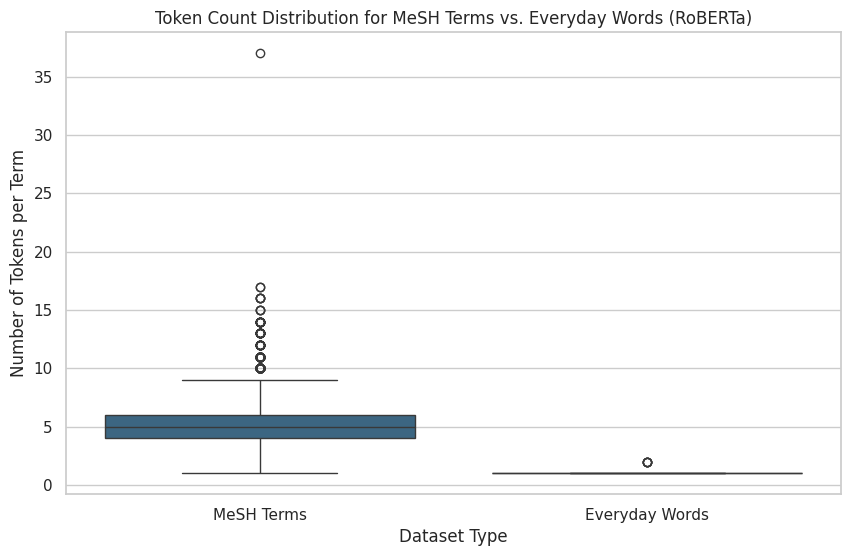

In [32]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=combined_df, x="Dataset_Type", y="Token_Count", palette="viridis")
plt.title("Token Count Distribution for MeSH Terms vs. Everyday Words (RoBERTa)")
plt.ylabel("Number of Tokens per Term")
plt.xlabel("Dataset Type")
plt.show()

**Reasoning**:
The previous code generated a `FutureWarning` from seaborn regarding the use of `palette` without `hue`. To address this, I will explicitly assign `x` to `hue` and set `legend=False` in the `sns.boxplot` function, as suggested by the warning.



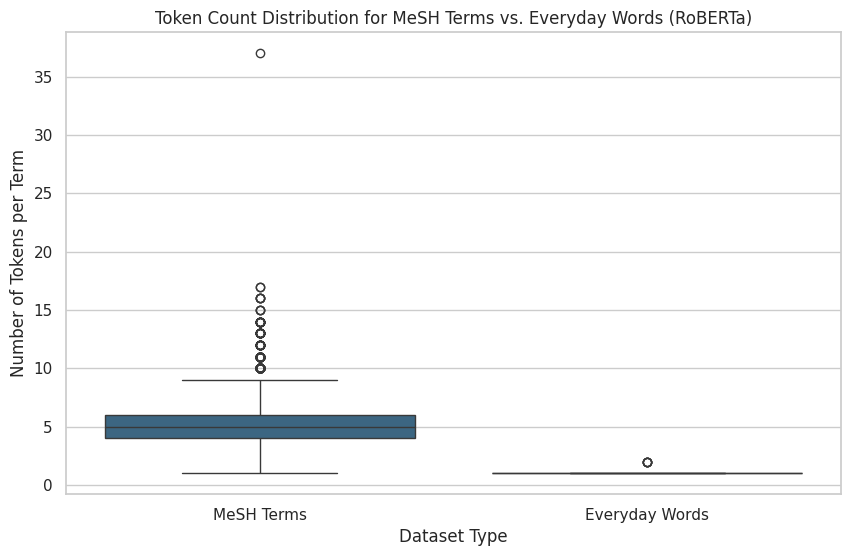

In [33]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=combined_df, x="Dataset_Type", y="Token_Count", hue="Dataset_Type", palette="viridis", legend=False)
plt.title("Token Count Distribution for MeSH Terms vs. Everyday Words (RoBERTa)")
plt.ylabel("Number of Tokens per Term")
plt.xlabel("Dataset Type")
plt.show()

**Reasoning**:
To visually compare the distribution of `Chars_per_Token` between 'MeSH Terms' and 'Everyday Words', I will create a boxplot, similar to how `Token_Count` was visualized. This will help in understanding the average character length per token for each dataset type.



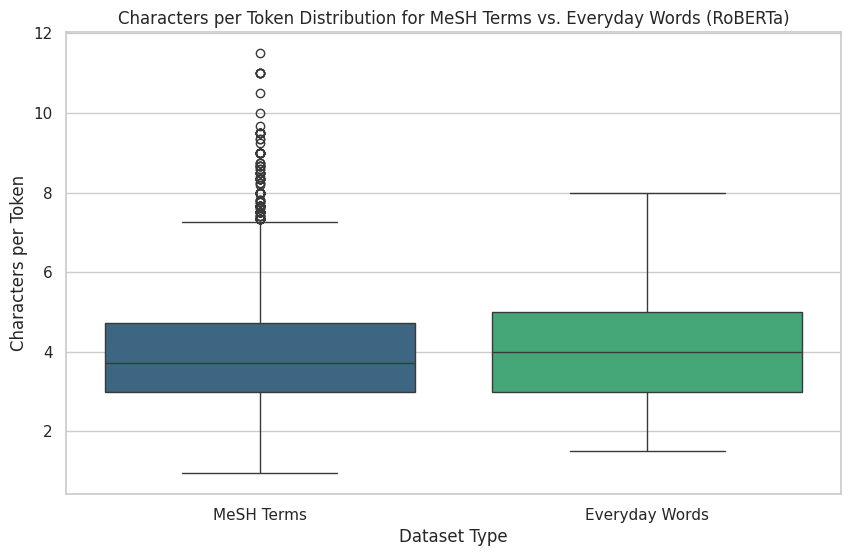

In [34]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=combined_df, x="Dataset_Type", y="Chars_per_Token", hue="Dataset_Type", palette="viridis", legend=False)
plt.title("Characters per Token Distribution for MeSH Terms vs. Everyday Words (RoBERTa)")
plt.ylabel("Characters per Token")
plt.xlabel("Dataset Type")
plt.show()

**Reasoning**:
To visually compare the distribution of `Fragmentation_Rate` between 'MeSH Terms' and 'Everyday Words', I will create a boxplot. This will help in understanding how often words are broken into single characters in each dataset.



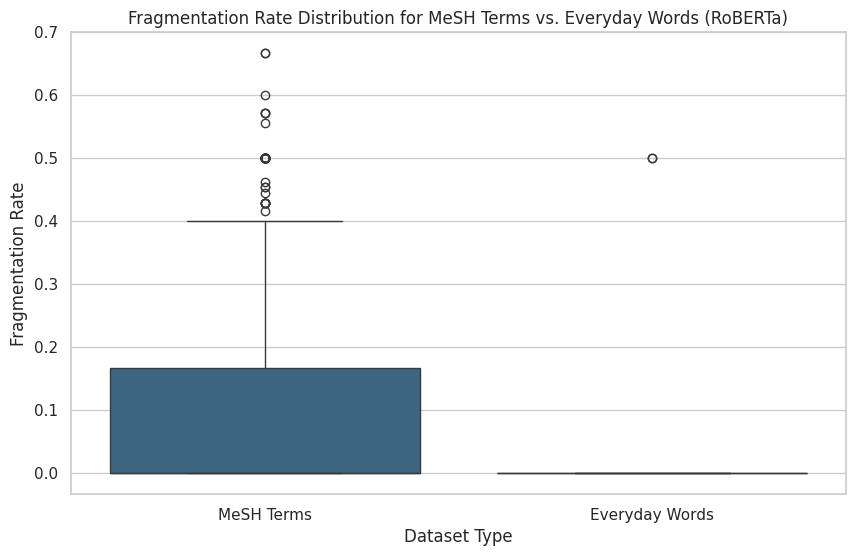

In [35]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=combined_df, x="Dataset_Type", y="Fragmentation_Rate", hue="Dataset_Type", palette="viridis", legend=False)
plt.title("Fragmentation Rate Distribution for MeSH Terms vs. Everyday Words (RoBERTa)")
plt.ylabel("Fragmentation Rate")
plt.xlabel("Dataset Type")
plt.show()

## Summary of RoBERTa Tokenizer Performance

### Comparison between MeSH Terms and Everyday Words:

1.  **Token Count (Number of Tokens per Term)**:
    *   **Everyday Words**: Generally require fewer tokens (median and mean are very low, around 1). This indicates that common English words are typically recognized as single tokens by RoBERTa.
    *   **MeSH Terms**: Require significantly more tokens (mean ~5.2, median ~5). This suggests that MeSH terms, being more specialized and often longer or multi-word concepts, are frequently broken down into multiple subword tokens by the RoBERTa tokenizer.

2.  **Chars per Token (Efficiency of Tokenization)**:
    *   **Everyday Words**: Show a higher average `Chars_per_Token` (mean ~4.12), indicating that each token tends to represent a larger chunk of characters. This aligns with single-token representations for many words.
    *   **MeSH Terms**: Have a slightly lower average `Chars_per_Token` (mean ~4.02), implying that while they use more tokens, the average character density per token is similar or slightly less efficient than for everyday words.

3.  **Fragmentation Rate (Proportion of Single-Character Tokens)**:
    *   **Everyday Words**: Have a very low fragmentation rate (mean ~0.02). This means that very few everyday words are broken down into single-character tokens, reinforcing that the tokenizer is familiar with these words.
    *   **MeSH Terms**: Exhibit a higher fragmentation rate (mean ~0.088). This indicates that a greater proportion of MeSH terms are tokenized into single characters, suggesting that the RoBERTa tokenizer is less familiar with these specialized medical terms and has to resort to more granular tokenization.

### Overall Observations:

*   **Vocabulary Mismatch**: The RoBERTa tokenizer, trained on general language, performs much more efficiently (fewer tokens, lower fragmentation) on common everyday words. This is expected as these words are likely well-represented in its pre-training data.
*   **Specialized Terminology**: For MeSH terms, the tokenizer shows signs of needing to break down words more often (higher token count, higher fragmentation rate). This implies that a model fine-tuned for biomedical text might exhibit better tokenization efficiency for MeSH terms, as it would likely have a larger vocabulary of such specialized terms.
*   **Implications**: When using RoBERTa for biomedical tasks, MeSH terms will likely consume more tokens, potentially impacting context window limits and computational cost, and may require more attention during downstream tasks due to higher fragmentation.

## Final Task

### Subtask:
According to the analysis results and charts, provide a summary report detailing the performance differences of the RoBERTa tokenizer on medical-related MeSH terms and everyday vocabulary datasets.


## Summary:

### Data Analysis Key Findings

*   **Token Count**: RoBERTa tokenizes everyday words into significantly fewer tokens (mean approximately 1.1) compared to specialized MeSH terms (mean approximately 5.2). This indicates that common words are often recognized as single units, while MeSH terms are frequently broken into multiple subword tokens.
*   **Characters per Token**: Everyday words exhibit a slightly higher average of 4.12 characters per token, while MeSH terms average around 4.02 characters per token. This suggests that the character density per token is similar across both datasets, even though MeSH terms use more tokens overall.
*   **Fragmentation Rate**: The fragmentation rate for everyday words is very low (mean approximately 0.02), implying infrequent breaking into single-character tokens. In contrast, MeSH terms show a notably higher fragmentation rate (mean approximately 0.088), indicating a greater tendency for the tokenizer to break them down into single characters.
*   **Visualization Consistency**: Box plots for Token Count, Characters per Token, and Fragmentation Rate visually confirmed these statistical differences, showing distinct distributions between MeSH terms and everyday words.

### Insights or Next Steps

*   **Vocabulary Mismatch**: The RoBERTa tokenizer, trained on general language, demonstrates higher efficiency (fewer tokens, lower fragmentation) on common everyday words due to better representation in its pre-training data. For specialized medical vocabulary like MeSH terms, the tokenizer resorts to more granular tokenization, suggesting a vocabulary mismatch.
*   **Implications for Biomedical NLP**: When applying RoBERTa to biomedical tasks, MeSH terms will likely consume more tokens, potentially impacting context window limits and increasing computational costs. This higher fragmentation also suggests that a domain-specific tokenizer or a RoBERTa model fine-tuned on biomedical text might yield better tokenization efficiency and performance for specialized terms.
